# 02 — Data Split & Sanity Check

Builds `data/manifest.csv` with columns `hr_path, lr_path, aoi, split`.

**Split strategy:**
- **Test**: `chicago-urban` and `sd-terrain-and-river` held out entirely — model never sees these scenes.
- **Train/Val**: remaining 15 scenes, random 85/15 tile-level split.
- No overlapping tiles, so no data leakage.

In [17]:
import sys
from pathlib import Path
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

sys.path.insert(0, str(Path('../src').resolve()))

HR_DIR   = Path('../data/tiles_hr')
LR_DIR   = Path('../data/tiles_lr')
MANIFEST = Path('../data/manifest.csv')

TEST_SCENES = ['chicago-urban', 'sd-terrain-and-river']
VAL_FRAC = 0.15
SEED = 42

print('Dirs exist:', HR_DIR.exists(), LR_DIR.exists())

Dirs exist: True True


## Step 1: Inventory

In [18]:
hr_files = sorted(HR_DIR.glob('*.png'))
print(f'Total HR tiles: {len(hr_files)}')

from collections import Counter
aoi_counts = Counter(f.stem.rsplit('_', 1)[0] for f in hr_files)
for aoi, count in sorted(aoi_counts.items()):
    print(f'  {aoi:<30} {count:>4} tiles')

Total HR tiles: 2295
  amazon-deforestation            132 tiles
  amazon-deforestation2           150 tiles
  boston-and-river                132 tiles
  chicago-urban                   140 tiles
  fishbone-deforestation          132 tiles
  iowa-farmland                   130 tiles
  iowa-farmland2                  132 tiles
  kansas-city-river               133 tiles
  long-beach-port                 132 tiles
  nebraska-farmland               132 tiles
  nj-port                         132 tiles
  port-of-la                      135 tiles
  port-of-savannah                132 tiles
  sd-farmland                     144 tiles
  sd-terrain-and-river            142 tiles
  tenesse-rainforest              132 tiles
  urban-philly                    133 tiles


## Step 2: Sanity check — every HR tile has a matching LR

In [19]:
missing = [f for f in hr_files if not (LR_DIR / f.name).exists()]
print(f'Missing LR pairs: {len(missing)}')
if missing:
    print('  ', [f.name for f in missing[:5]])

# Check a sample of shapes
import random
sample = random.sample(hr_files, min(10, len(hr_files)))
shape_ok = True
for hr_path in sample:
    hr = np.array(Image.open(hr_path))
    lr = np.array(Image.open(LR_DIR / hr_path.name))
    if hr.shape != (128, 128, 3) or lr.shape != (32, 32, 3):
        print(f'  BAD shapes: {hr_path.name}  HR={hr.shape}  LR={lr.shape}')
        shape_ok = False
if shape_ok:
    print('Shape check passed: all sampled tiles are 128x128 HR / 32x32 LR')

Missing LR pairs: 0
Shape check passed: all sampled tiles are 128x128 HR / 32x32 LR


## Step 3: Build and save manifest

In [20]:
random.seed(SEED)

rows = []
for hr_path in hr_files:
    aoi = hr_path.stem.rsplit('_', 1)[0]
    rows.append({
        'hr_path': str(hr_path.resolve()),
        'lr_path': str((LR_DIR / hr_path.name).resolve()),
        'aoi':     aoi,
        'split':   'pending',
    })

df = pd.DataFrame(rows)

# Test: held-out scenes (model never sees these)
df.loc[df['aoi'].isin(TEST_SCENES), 'split'] = 'test'

# Train/val: random 85/15 split on remaining tiles
train_val_idx = df[df['split'] == 'pending'].index.tolist()
random.shuffle(train_val_idx)
n_val = int(len(train_val_idx) * VAL_FRAC)

df.loc[train_val_idx[:n_val], 'split'] = 'val'
df.loc[df['split'] == 'pending', 'split'] = 'train'

df.to_csv(MANIFEST, index=False)

print(df.groupby(['aoi', 'split']).size().unstack(fill_value=0).to_string())
print(f'\nTotal  train={(df.split=="train").sum()}  val={(df.split=="val").sum()}  test={(df.split=="test").sum()}')
print(f'Manifest saved → {MANIFEST}')

split                   test  train  val
aoi                                     
amazon-deforestation       0    113   19
amazon-deforestation2      0    127   23
boston-and-river           0    109   23
chicago-urban            140      0    0
fishbone-deforestation     0    121   11
iowa-farmland              0    103   27
iowa-farmland2             0    122   10
kansas-city-river          0    113   20
long-beach-port            0    111   21
nebraska-farmland          0    112   20
nj-port                    0    109   23
port-of-la                 0    115   20
port-of-savannah           0    108   24
sd-farmland                0    122   22
sd-terrain-and-river     142      0    0
tenesse-rainforest         0    121   11
urban-philly               0    106   27

Total  train=1712  val=301  test=282
Manifest saved → ../data/manifest.csv


## Step 4: Pixel value distributions per AOI

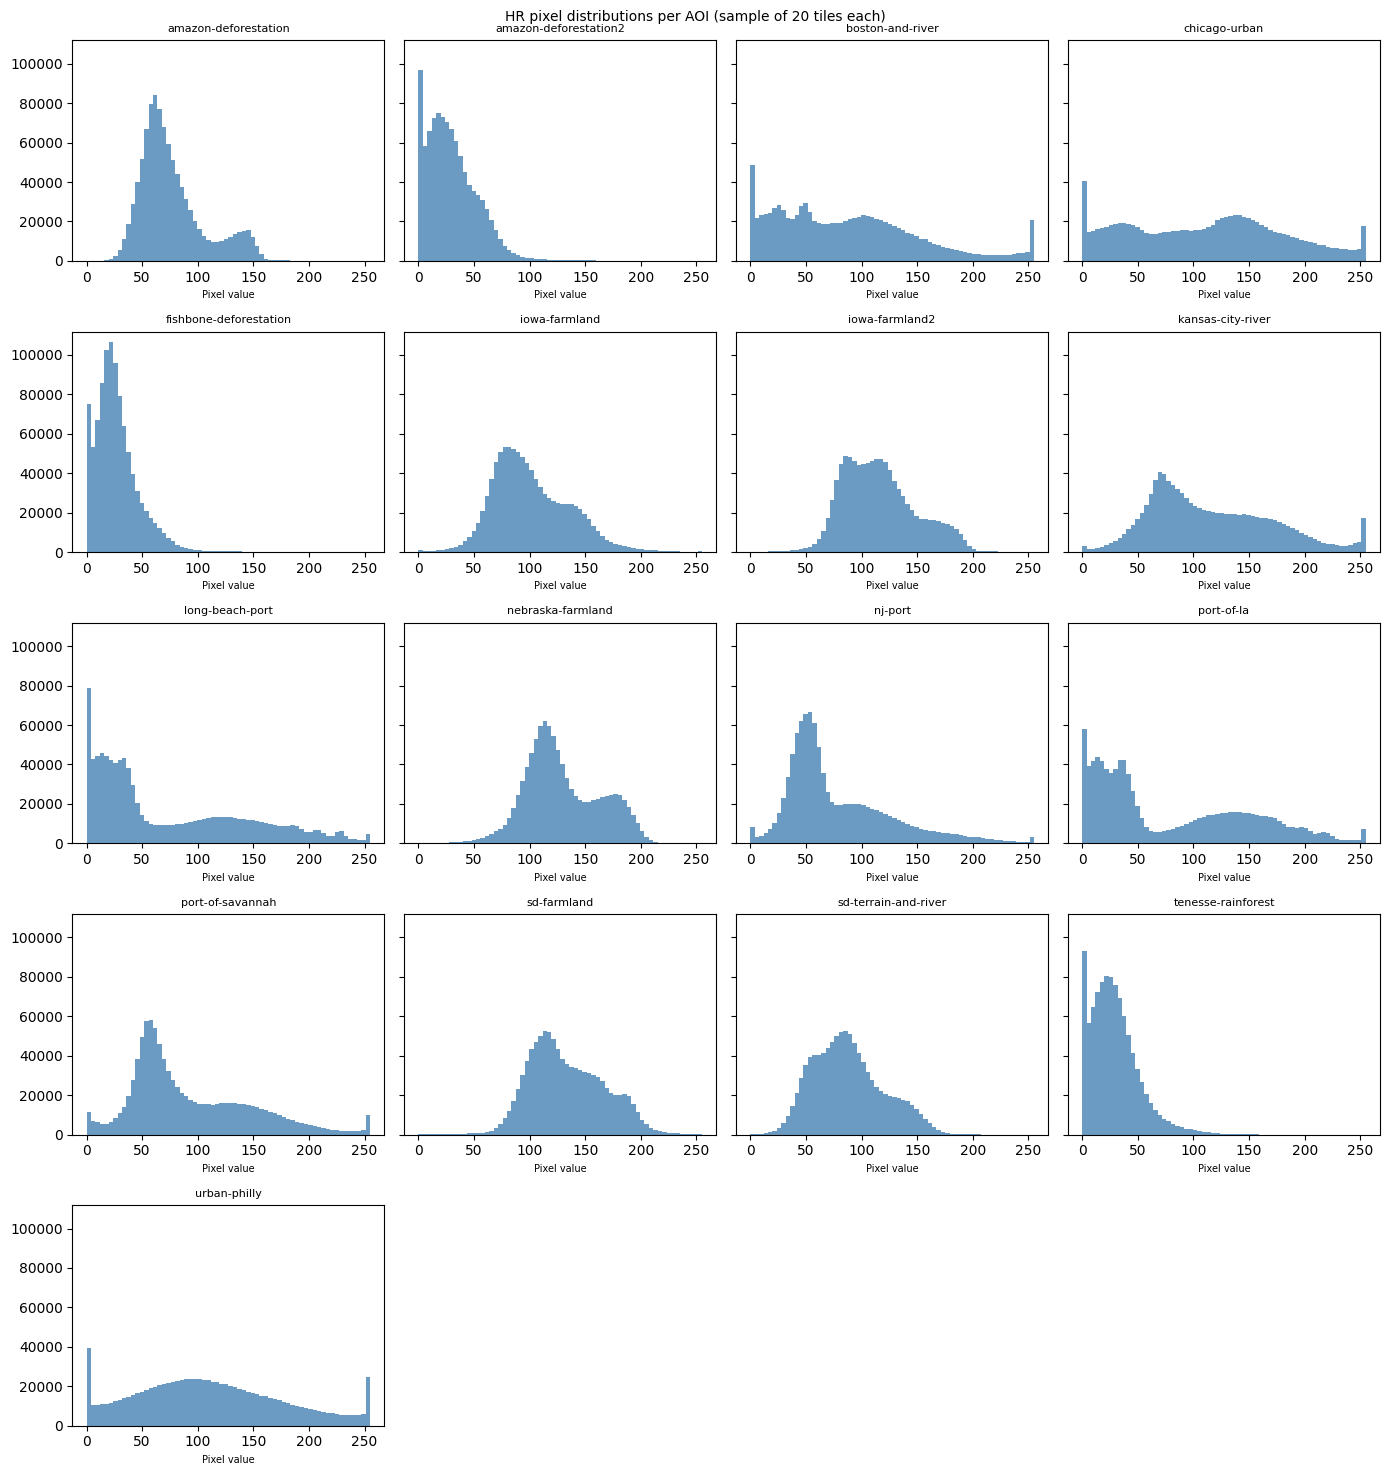

In [21]:
aois = sorted(set(f.stem.rsplit('_', 1)[0] for f in hr_files))
n_aois = len(aois)
ncols = 4
nrows = (n_aois + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3 * nrows), sharey=True)
axes = axes.flat

for i, aoi in enumerate(aois):
    aoi_files = [f for f in hr_files if f.stem.rsplit('_', 1)[0] == aoi]
    sample = random.sample(aoi_files, min(20, len(aoi_files)))
    pixels = np.concatenate([np.array(Image.open(f)).ravel() for f in sample])
    axes[i].hist(pixels, bins=64, range=(0, 255), color='steelblue', alpha=0.8)
    axes[i].set_title(aoi, fontsize=8)
    axes[i].set_xlabel('Pixel value', fontsize=7)

for j in range(i + 1, nrows * ncols):
    axes[j].set_visible(False)

fig.suptitle('HR pixel distributions per AOI (sample of 20 tiles each)', fontsize=10)
plt.tight_layout()
plt.show()